## Initialize The Required Modules  

In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Provide a grid for the plots
sns.set(style='whitegrid')

## Provide The Data

In [3]:
# Provide the path to the data
path = '../data/*.csv'

# Get all CSV files
files = glob.glob(path)

# Load and concatenate all the data
df_list = [pd.read_csv(file) for file in files]
df = pd.concat(df_list, ignore_index=True)

# Preview data
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member


## Initial Check of The Data Structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5601662 entries, 0 to 5601661
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 555.6+ MB


## Convert Date columns to The Right Data Type

In [5]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Check if the conversion was processed properly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5601662 entries, 0 to 5601661
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(4), object(7)
memory usage: 555.6+ MB


## Adding Some Useful Columns

In [6]:
# Ride duration in minutes
df['ride_length'] = (df['ended_at']- df['started_at']).dt.total_seconds() / 60

# Day of week
df['day_of_week'] = df['started_at'].dt.day_name()

# Month
df['month'] = df['started_at'].dt.month_name()

df.head(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length,day_of_week,month
0,FD0EB1D32AF0D47E,classic_bike,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302,Central St & Girard Ave,CHI02042,Dodge Ave & Church St,CHI00741,42.064313,-87.686152,42.048308,-87.698224,member,15.021400,Saturday,January
1,FB27405C3F8C824F,classic_bike,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854,Shore Dr & 55th St,CHI00394,Woodlawn Ave & 55th St,CHI00423,41.795212,-87.580715,41.795264,-87.596471,casual,7.605467,Thursday,January
2,6FAFA1709403AA27,electric_bike,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922,Hampden Ct & Diversey Pkwy,CHI02087,NaN,NaN,41.932470,-87.642420,41.940000,-87.640000,member,6.739167,Tuesday,January
3,1F34C1FAD9FEC2D8,electric_bike,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197,Carpenter St & Huron St,CHI00286,NaN,NaN,41.894532,-87.653412,41.830000,-87.670000,member,30.836433,Monday,January
4,8E3E3072D8D3D918,electric_bike,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971,Clinton St & Madison St,CHI00233,NaN,NaN,41.881660,-87.641150,41.890000,-87.630000,member,78.447200,Saturday,January


## Data Cleaning

In [7]:
# Remove negative or zero ride durations
df = df[df['ride_length'] > 0]

# Remove extremely long rides (outliers)
df = df[df['ride_length'] < 1440] # less than 24 hours

# Quick check
df['member_casual'].value_counts()

member_casual
member    3587121
casual    2008748
Name: count, dtype: int64

## Exploratory Data Analysis
### Average Ride Length

In [8]:
df.groupby('member_casual')['ride_length'].mean()

member_casual
casual    19.131878
member    12.013578
Name: ride_length, dtype: float64

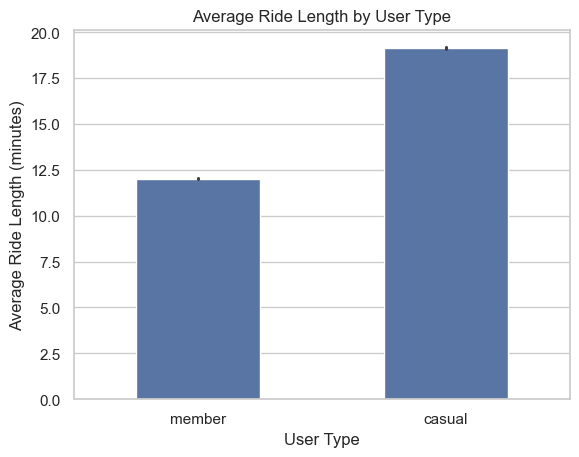

In [ ]:
# Visualization
sns.barplot(data=df, x='member_casual', y='ride_length', width=0.5)
plt.xlabel('User Type')
plt.ylabel('Average Ride Length (minutes)')
plt.title('Average Ride Length by User Type')
plt.show()

### Usage by Day of Week

In [15]:
df.groupby(['day_of_week', 'member_casual']).size().reset_index(name='count')

,day_of_week,member_casual,count
0,Friday,casual,322020
1,Friday,member,533866
2,Monday,casual,229915
3,Monday,member,506257
4,Saturday,casual,414913
5,Saturday,member,452291
6,Sunday,casual,333078
7,Sunday,member,382597
8,Thursday,casual,258352
9,Thursday,member,578424


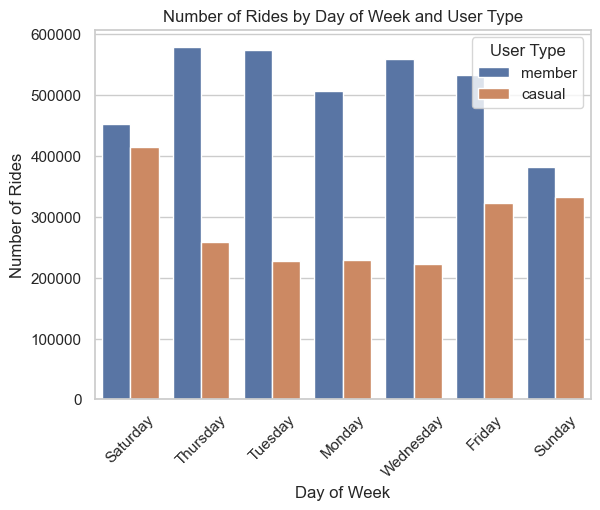

In [ ]:
# Visualization
sns.countplot(data=df, x='day_of_week', hue='member_casual')
plt.xticks(rotation=45)
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.title('Number of Rides by Day of Week and User Type')
plt.legend(title='User Type')
plt.show()


### Usage by Month

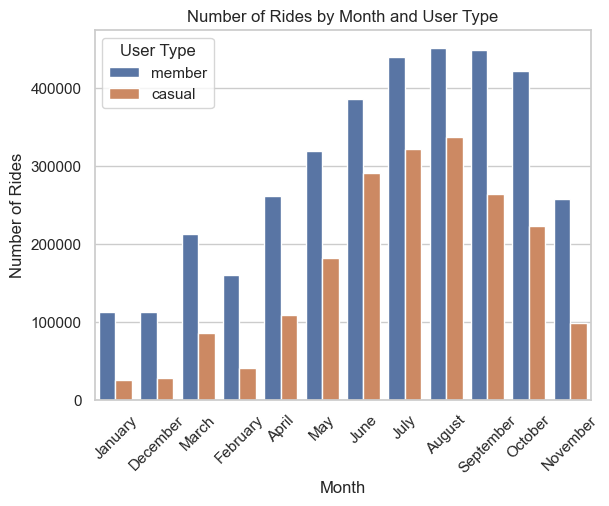

In [ ]:
# visualization
sns.countplot(data=df, x='month', hue='member_casual')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.title('Number of Rides by Month and User Type')
plt.legend(title='User Type')
plt.show()

### Rideable Type Preference

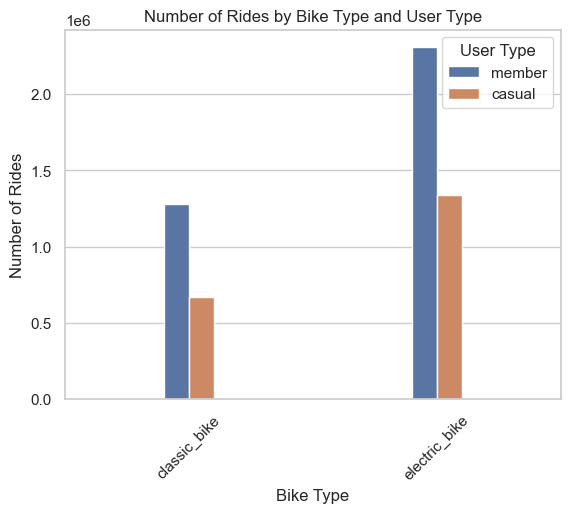

In [ ]:
sns.countplot(data=df, x='rideable_type', hue='member_casual', width=0.2)
plt.xticks(rotation=45)
plt.xlabel('Bike Type')
plt.ylabel('Number of Rides')
plt.title('Number of Rides by Bike Type and User Type')
plt.legend(title='User Type')
plt.show()

## Key Insights

**Casual riders take longer trips than members**  
   Casual riders have a higher average ride duration, suggesting they use bikes for leisure and exploration rather than daily commuting.

**Members use bikes more consistently during weekdays**  
   Annual members show higher usage during weekdays, indicating that they primarily use bikes for commuting or routine travel.

**Casual riders are more active on weekends**  
   Casual riders peak on weekends, which reinforces the idea that they use the service for recreational purposes.

**Seasonality affects both user types**  
   Usage increases during warmer months, with a noticeable peak in summer. Casual riders show a stronger seasonal pattern compared to members.

**Bike type preferences differ slightly**  
   Both groups use classic bikes the most, but casual riders tend to use electric bikes slightly more often.


## Recommendations
**Target casual riders with weekend promotions**  
Since casual riders are most active on weekends, Cyclistic should offer weekend-only membership discounts or trial memberships to encourage conversion.

**Promote membership as a commuting solution**  
Highlight cost savings and convenience for frequent riders, especially targeting users who ride during weekdays.

**Seasonal marketing campaigns**  
Launch campaigns during spring and summer when ridership is highest, focusing on converting casual riders into annual members.

**Incentivize longer rides into memberships**
Since casual users take longer trips, offer discounts or rewards for frequent long rides that can be redeemed toward a membership.  